In [9]:
%pip install -q langgraph==0.3.31 
%pip install -q langchain-ibm==0.3.10
%pip install -q langchain==0.3.23
%pip install -q langchain_community==0.3.21 
%pip install -q pygraphviz==1.14

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
OPENAI_ORG_ID = os.getenv("OPENAI_ORG_ID", "")

# Model Configuration
DEFAULT_MODEL = os.getenv("DEFAULT_MODEL", "gpt-3.5-turbo")
TEMPERATURE = float(os.getenv("TEMPERATURE", "0.7"))
MAX_TOKENS = int(os.getenv("MAX_TOKENS", "500"))
WATSON_URL = os.getenv("IBM_URL_END_POINT")
PROJECT_ID = os.getenv("IBM_PROJECT_ID")
IBM_API_KEY = os.getenv("IBM_API_KEY")


In [11]:
from langchain_ibm import ChatWatsonx
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import END, MessageGraph, StateGraph

from typing import List, Sequence
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [12]:
# IGNORE IF YOU ARE NOT RUNNING LOCALLY
from langchain_ibm import ChatWatsonx
watsonx_llm = ChatWatsonx(
    model_id="ibm/granite-8b-code-instruct",
    url="https://us-south.ml.cloud.ibm.com",
    project_id=PROJECT_ID,
    apikey=IBM_API_KEY,
)

In [13]:
llm = ChatWatsonx(
    model_id="ibm/granite-8b-code-instruct",
    url=WATSON_URL,
    project_id=PROJECT_ID,
    apikey=IBM_API_KEY,
)

In [14]:
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional LinkedIn content assistant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
            " Generate the best LinkedIn post possible for the user's request."
            " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [15]:
generate_chain = generation_prompt | llm

In [16]:
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        Your critique will be used to improve the post in the next revision step, so ensure your feedback is thoughtful, constructive, and practical.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

In [17]:
reflect_chain = reflection_prompt | llm

In [18]:
from langgraph.graph import MessageGraph
from typing import List, Annotated, TypedDict
from langchain.schema import HumanMessage, AIMessage, SystemMessage

# Initialize a predefined MessageGraph
graph = MessageGraph()

In [19]:
def generation_node(state: Sequence[BaseMessage]) -> List[BaseMessage]:
    generated_post = generate_chain.invoke({"messages": state})
    return [AIMessage(content=generated_post.content)]

In [20]:
def reflection_node(messages: Sequence[BaseMessage]) -> List[BaseMessage]:
    res = reflect_chain.invoke({"messages": messages})  # Passes messages as input to reflect_chain
    return [HumanMessage(content=res.content)]  # Returns the refined message as HumanMessage for feedback

In [21]:
graph.add_node("generate", generation_node)

In [22]:
graph.add_node("reflect", reflection_node)

In [23]:
graph.add_edge("reflect", "generate")


In [24]:
graph.set_entry_point("generate")

In [25]:
def should_continue(state: List[BaseMessage]):
    print(state)
    print(len(state))
    print("----------------------------------------------------------------------")
    if len(state) > 6:
        return END
    return "reflect"

In [26]:
graph.add_conditional_edges("generate", should_continue)

In [27]:
workflow = graph.compile()

In [28]:
inputs = HumanMessage(content="""Write a linkedin post on getting a software developer job at IBM under 160 characters""")

In [29]:
response = workflow.invoke(inputs)

[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='5b951614-d520-4f43-a9e2-f35c64f88120'), AIMessage(content='\n"Looking for a software developer job at IBM? I\'m a recent graduate from [insert your degree and major], and I\'m excited about the endless opportunities in this field. With my experience in [insert relevant skills], I\'m confident I can hit the ground running. I\'m also passionate about [insert relevant interest], and I\'d love to use my skills to make a real impact. Let\'s talk more at my availability! #softwaredev #IBM #careeropportunity"', additional_kwargs={}, response_metadata={}, id='880eef21-e46e-4c10-9dc8-f50d889dc450')]
2
----------------------------------------------------------------------
[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='5b951614-d5

In [30]:
response[1].content

'\n"Looking for a software developer job at IBM? I\'m a recent graduate from [insert your degree and major], and I\'m excited about the endless opportunities in this field. With my experience in [insert relevant skills], I\'m confident I can hit the ground running. I\'m also passionate about [insert relevant interest], and I\'d love to use my skills to make a real impact. Let\'s talk more at my availability! #softwaredev #IBM #careeropportunity"'

In [31]:
response[2].content

'\n"Looking for a software developer job at IBM? I\'m a recent graduate from [insert your degree and major], and I\'m excited about the endless opportunities in this field. With my experience in [insert relevant skills], I\'m confident I can hit the ground running. I\'m also passionate about [insert relevant interest], and I\'d love to use my skills to make a real impact. Let\'s talk more at my availability! #softwaredev #IBM #careeropportunity"'

In [32]:
response[-1].content

'\n"Looking for a software developer job at IBM? I\'m a recent graduate from [insert your degree and major], and I\'m excited about the endless opportunities in this field. With my experience in [insert relevant skills], I\'m confident I can hit the ground running. I\'m also passionate about [insert relevant interest], and I\'d love to use my skills to make a real impact. Let\'s talk more at my availability! #softwaredev #IBM #careeropportunity"'

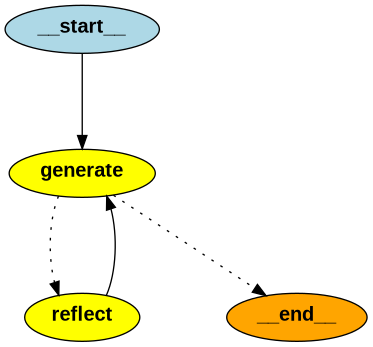

In [33]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_png()))